# Análisis de vulnerabilidades y componentes de la organización Vercel

## Introducción

Este notebook presenta un descriptivo de los resultados obtenidos durante la extracción realizada por el _miner_ a los 25 proyectos más populares de Vercel.
Por tanto, se analizarán los datos integrandos por el SBOM, posteriormente el análisis estático de cada repositorio, y finalmente las vulnerabilidades encontradas en las dependencias.

### Configuración inicial

La siguiente fracción de código establece los directorios para obtener la información requerida.

In [1]:
import sys
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Setup de rutas
PROYECT_ROOT = Path().cwd().parent
RESULTS_FOLDER = PROYECT_ROOT / "results"

print(f"Directorio de resultados: {RESULTS_FOLDER}")
print(f"Proyecto raíz: {PROYECT_ROOT}")

Directorio de resultados: /Users/mgci/Universidad/Semestre-8/Ciberseguridad/Proyecto-Ciberseguridad/results
Proyecto raíz: /Users/mgci/Universidad/Semestre-8/Ciberseguridad/Proyecto-Ciberseguridad


## Componentes, librerías y modulos utilizados: SBOMS

In [2]:
# Cargar datos de SBOMs
sboms_files = sorted(RESULTS_FOLDER.glob("*-sbom.json"))

print(f"Buscando archivos SBOMS en: {RESULTS_FOLDER}")
print(f"Archivos SBOMS encontrados: {len(sboms_files)}")

sboms_data = []

for file in sboms_files:
    print(f"Cargando SBOM desde: {file}")
    repo_name = file.stem.replace("-sbom", "")
    with open(file, "r", encoding="utf-8") as f:
        data = json.load(f)
    for artifact in data.get("artifacts", []):
        sboms_data.append({
            "repo": repo_name,
            "artifact_name": artifact.get("name"),
            "artifact_version": artifact.get("version"),
            "artifact_type": artifact.get("type"),
            "purl": artifact.get("purl"),
            "language": artifact.get("language"),
            "dependencies_count": len(artifact.get("dependencies", [])),
            "licenses": artifact.get("licenses", [])
        })

sboms_df = pd.DataFrame(sboms_data)
sboms_df.head()

Buscando archivos SBOMS en: /Users/mgci/Universidad/Semestre-8/Ciberseguridad/Proyecto-Ciberseguridad/results
Archivos SBOMS encontrados: 25
Cargando SBOM desde: /Users/mgci/Universidad/Semestre-8/Ciberseguridad/Proyecto-Ciberseguridad/results/ai-sbom.json
Cargando SBOM desde: /Users/mgci/Universidad/Semestre-8/Ciberseguridad/Proyecto-Ciberseguridad/results/chatbot-sbom.json
Cargando SBOM desde: /Users/mgci/Universidad/Semestre-8/Ciberseguridad/Proyecto-Ciberseguridad/results/commerce-sbom.json
Cargando SBOM desde: /Users/mgci/Universidad/Semestre-8/Ciberseguridad/Proyecto-Ciberseguridad/results/eve-sbom.json
Cargando SBOM desde: /Users/mgci/Universidad/Semestre-8/Ciberseguridad/Proyecto-Ciberseguridad/results/examples-sbom.json
Cargando SBOM desde: /Users/mgci/Universidad/Semestre-8/Ciberseguridad/Proyecto-Ciberseguridad/results/hazel-sbom.json
Cargando SBOM desde: /Users/mgci/Universidad/Semestre-8/Ciberseguridad/Proyecto-Ciberseguridad/results/hyper-sbom.json
Cargando SBOM desde: /U

,repo,artifact_name,artifact_version,artifact_type,purl,language,dependencies_count,licenses
0,ai,@adobe/css-tools,4.4.4,npm,pkg:npm/%40adobe/css-tools@4.4.4,javascript,0,[]
1,ai,@agentclientprotocol/claude-agent-acp,0.61.0,npm,pkg:npm/%40agentclientprotocol/claude-agent-ac...,javascript,0,[]
2,ai,@agentclientprotocol/codex-acp,1.1.4,npm,pkg:npm/%40agentclientprotocol/codex-acp@1.1.4,javascript,0,[]
3,ai,@agentclientprotocol/sdk,1.2.1,npm,pkg:npm/%40agentclientprotocol/sdk@1.2.1,javascript,0,[]
4,ai,@agentclientprotocol/sdk,1.3.0,npm,pkg:npm/%40agentclientprotocol/sdk@1.3.0,javascript,0,[]


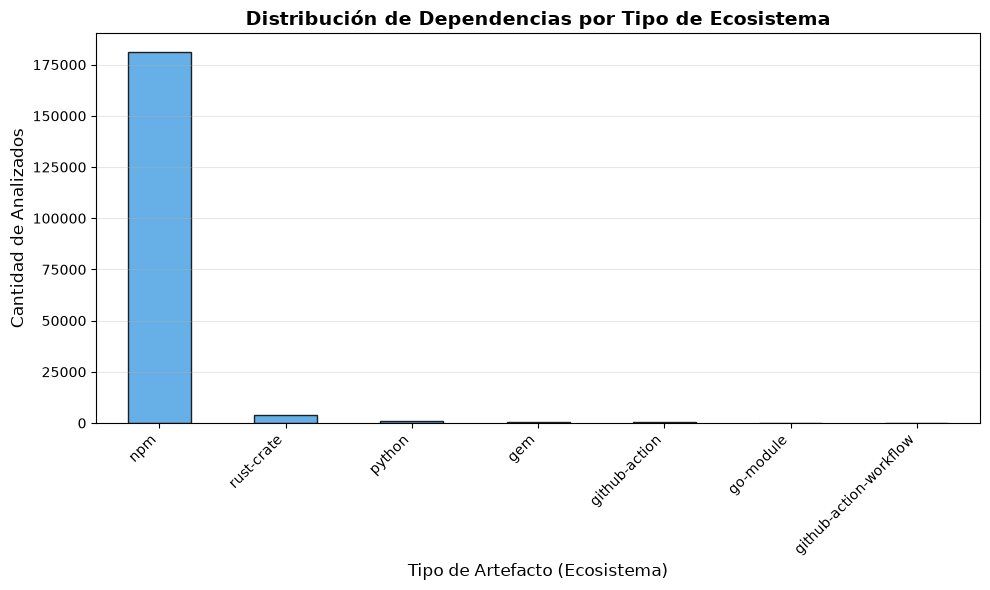

Datos de SBOM exportados a: /Users/mgci/Universidad/Semestre-8/Ciberseguridad/Proyecto-Ciberseguridad/results/sbom-analisis/sbom-ecosistemas.json


In [4]:
if len(sboms_df) > 0:
    fig, ax = plt.subplots(figsize=(10, 6))

    type_counts = sboms_df['artifact_type'].value_counts()

    type_counts.plot(kind='bar', ax=ax, color='#4ba3e3', edgecolor='black', alpha=0.85)

    ax.set_title('Distribución de Dependencias por Tipo de Ecosistema', fontsize=14, fontweight='bold')
    ax.set_xlabel('Tipo de Artefacto (Ecosistema)', fontsize=12)
    ax.set_ylabel('Cantidad de Analizados', fontsize=12)

    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

    export_sbom = {
        "total_repos": int(sboms_df['repo'].nunique()),
        "ecosystems": []
    }

    for artifact_type, count in type_counts.items():
        export_sbom["ecosystems"].append({
            "type": str(artifact_type),
            "count": int(count)
        })

    output_sbom_path = RESULTS_FOLDER / "sbom-analisis" / "sbom-ecosistemas.json"
    output_sbom_path.parent.mkdir(parents=True, exist_ok=True)

    with open(output_sbom_path, 'w', encoding='utf-8') as f:
        json.dump(export_sbom, f, indent=4)

    print(f"Datos de SBOM exportados a: {output_sbom_path}")

else:
    print("No hay datos de SBOM disponibles para graficar")

Se detecta que la gran mayoría de dependencias son de _npm_, seguidas por las de _rust_.

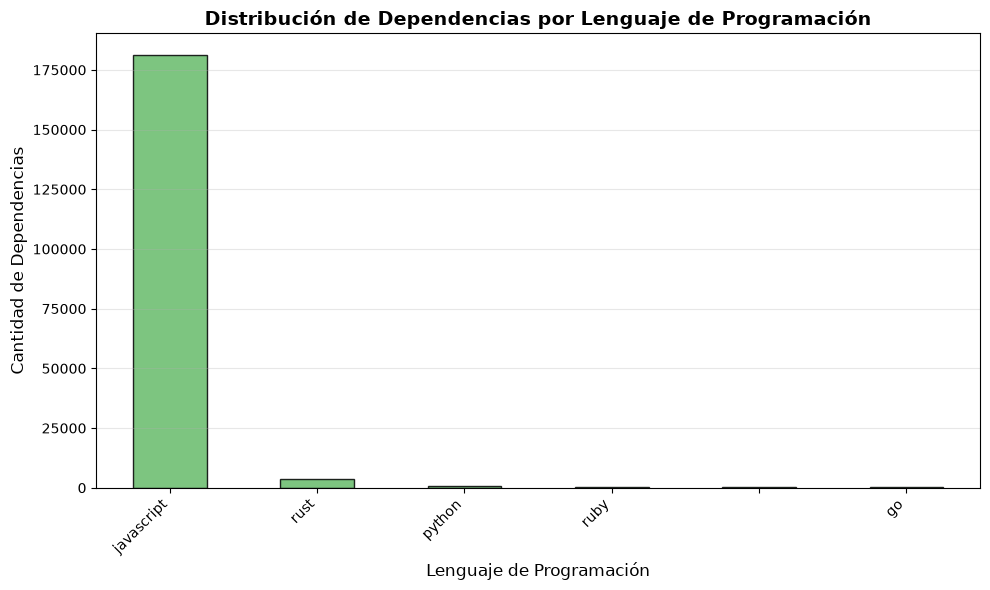

Datos de lenguajes SBOM exportados a: /Users/mgci/Universidad/Semestre-8/Ciberseguridad/Proyecto-Ciberseguridad/results/sbom-analisis/sbom-lenguajes.json


In [5]:
if len(sboms_df) > 0 and 'language' in sboms_df.columns:
    fig, ax = plt.subplots(figsize=(10, 6))
    lang_counts = sboms_df['language'].dropna().value_counts()
    lang_counts.plot(kind='bar', ax=ax, color='#66bb6a', edgecolor='black', alpha=0.85)
    ax.set_title('Distribución de Dependencias por Lenguaje de Programación', fontsize=14, fontweight='bold')
    ax.set_xlabel('Lenguaje de Programación', fontsize=12)
    ax.set_ylabel('Cantidad de Dependencias', fontsize=12)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    export_lang = []
    for lang, count in lang_counts.items():
        if str(lang).strip(): 
            export_lang.append({
                "language": str(lang),
                "count": int(count)
            })
    
    output_lang_path = RESULTS_FOLDER / "sbom-analisis" /"sbom-lenguajes.json"
    with open(output_lang_path, 'w', encoding='utf-8') as f:
        json.dump(export_lang, f, indent=4)
        
    print(f"Datos de lenguajes SBOM exportados a: {output_lang_path}")

else:
    print("No hay datos disponibles para graficar.")

De forma análoga a lo anterior, se muestra la misma distribución de la frecuencia de los lenguajes de programación.

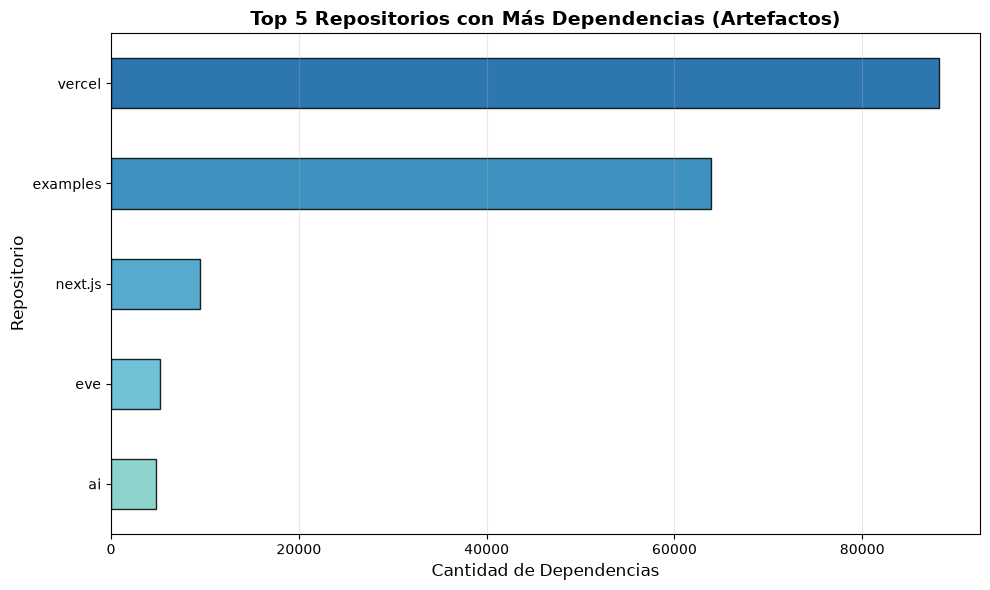

Datos del Top 5 repositorios SBOM exportados a: /Users/mgci/Universidad/Semestre-8/Ciberseguridad/Proyecto-Ciberseguridad/results/sbom-analisis/sbom-top-repos.json


In [6]:
if len(sboms_df) > 0:
    fig, ax = plt.subplots(figsize=(10, 6))
    top_repos = sboms_df['repo'].value_counts().head(5)
    colores = plt.cm.GnBu(np.linspace(0.5, 0.9, len(top_repos)))
    top_repos_sorted = top_repos.sort_values(ascending=True)
    top_repos_sorted.plot(kind='barh', ax=ax, color=colores, edgecolor='black', alpha=0.85)

    ax.set_title('Top 5 Repositorios con Más Dependencias (Artefactos)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Cantidad de Dependencias', fontsize=12)
    ax.set_ylabel('Repositorio', fontsize=12)
    ax.grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()

    export_top_repos = []
    for repo, count in top_repos.items():
        export_top_repos.append({
            "repo": str(repo),
            "count": int(count)
        })

    output_repo_path = RESULTS_FOLDER / "sbom-analisis" /"sbom-top-repos.json"
    with open(output_repo_path, 'w', encoding='utf-8') as f:
        json.dump(export_top_repos, f, indent=4)

    print(f"Datos del Top 5 repositorios SBOM exportados a: {output_repo_path}")

else:
    print("No hay datos de SBOM disponibles para analizar")

En base a los 3 repositorios con más dependencias se destancan los siguientes:
- _Vercel_: permite realizar _deploys_ de forma sencilla (SaaS).
- _examples_: provee instancias de inicialización o soluciones para orientar sobre el funcionamiento de _Vercel_.
- _Next.js_: un _framework_ de _React_ que extiende sus características y es integrado con tooling de Javascript con Rust para acelerar sus builds.

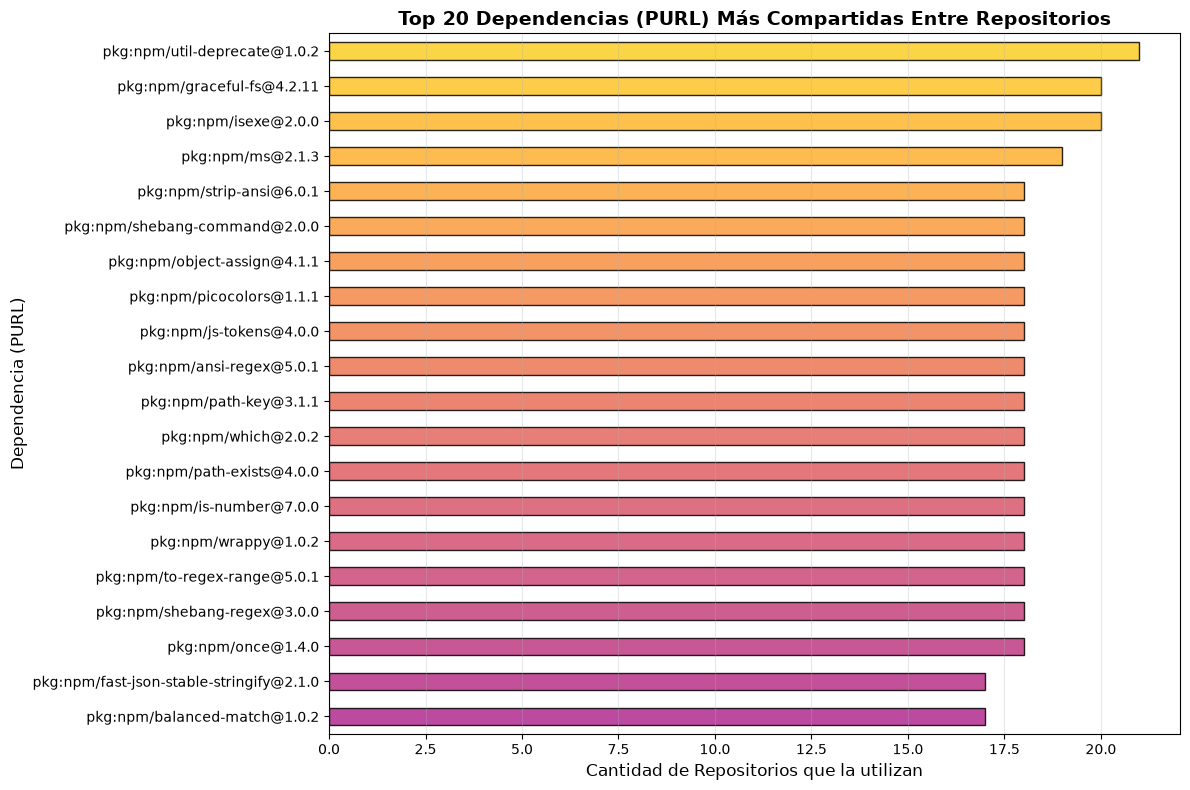

Datos de PURLs más compartidos exportados a: /Users/mgci/Universidad/Semestre-8/Ciberseguridad/Proyecto-Ciberseguridad/results/sbom-analisis/sbom-purls.json


In [7]:
if len(sboms_df) > 0 and 'purl' in sboms_df.columns:
    fig, ax = plt.subplots(figsize=(12, 8))

    common = (
        sboms_df.dropna(subset=["purl"])
        .groupby("purl")["repo"].nunique()
        .sort_values(ascending=False)
    ).head(20)
    
    common_sorted = common.sort_values(ascending=True)
    colores = plt.cm.plasma(np.linspace(0.4, 0.9, len(common_sorted)))
    common_sorted.plot(kind='barh', ax=ax, color=colores, edgecolor='black', alpha=0.85)

    ax.set_title('Top 20 Dependencias (PURL) Más Compartidas Entre Repositorios', fontsize=14, fontweight='bold')
    ax.set_xlabel('Cantidad de Repositorios que la utilizan', fontsize=12)
    ax.set_ylabel('Dependencia (PURL)', fontsize=12)
    ax.grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()

    export_purls = []
    for purl, count in common.items():
        export_purls.append({
            "purl": str(purl),
            "count": int(count)
        })

    output_purls_path = RESULTS_FOLDER / "sbom-analisis" /"sbom-purls.json"
    with open(output_purls_path, 'w', encoding='utf-8') as f:
        json.dump(export_purls, f, indent=4)

    print(f"Datos de PURLs más compartidos exportados a: {output_purls_path}")

else:
    print("No hay datos de 'purl' disponibles para analizar en sboms_df")

Al análizar las 20 dependencias más compartidas entre repositorios se puede apreciar una tendencia ligada a dependencias del ecosistema de _JavaScript_, las cuales en general mejoran _Node.js_ por medio de funcionalidades extra como marcar funciones obsoletas, lista-diccionario para mapear nombres de colores a sus códigos HEX y RGB, o client-only que evita importar código de componentes de tipo client-side a server-side rendering.

## Análisis CodeQL: Vulnerabilidades en Código Fuente

In [16]:
# Cargar todos los análisis CodeQL
codeql_files = sorted(RESULTS_FOLDER.glob("*-codeql.json"))

print(f"\nBuscando archivos CodeQL en: {RESULTS_FOLDER}")
print(f"Archivos encontrados: {len(codeql_files)}\n")

data_consolidado = []

for archivo in codeql_files:
    with open(archivo, 'r', encoding='utf-8') as f:
        contenido = json.load(f)

    repo_name = archivo.stem.replace('-codeql', '')
    issues = contenido.get('issues', [])

    for issue in issues:
        issue['repo'] = repo_name
        data_consolidado.append(issue)

df_codeql = pd.DataFrame(data_consolidado)

print(f"Total de problemas cargados: {len(df_codeql)}")
print(
    f"Repositorios únicos: {df_codeql['repo'].nunique() if len(df_codeql) > 0 else 0}\n")


Buscando archivos CodeQL en: /Users/mgci/Universidad/Semestre-8/Ciberseguridad/Proyecto-Ciberseguridad/results
Archivos encontrados: 25

Total de problemas cargados: 7138
Repositorios únicos: 19



Si bien se analizaron 25 repositorios,  solo se crearon 19 archivos codeql, ya que 6 de los repositorios no contaban con vulnerabilidades. 

In [17]:
# Estadísticas por severidad
if len(df_codeql) > 0:
    stats_severity = df_codeql['level'].value_counts().sort_index(ascending=False)

    print("Problemas por Nivel de Severidad:")
    print("=" * 50)
    for nivel, cantidad in stats_severity.items():
        porcentaje = (cantidad / len(df_codeql)) * 100
        print(f"{nivel.upper()}: {cantidad} ({porcentaje:.1f}%)")

    df_export = stats_severity.reset_index()
    df_export.columns = ['level', 'count']
    
    output_path = RESULTS_FOLDER / "codeql-analisis" / "estadisticas-severidad.json"
    output_path.parent.mkdir(parents=True, exist_ok=True)

    df_export.to_json(output_path, orient='records', indent=4)
    print(f"\nDatos de severidad exportados a: {output_path}")

else:
    print("No hay datos de CodeQL disponibles")

Problemas por Nivel de Severidad:

Datos de severidad exportados a: /Users/mgci/Universidad/Semestre-8/Ciberseguridad/Proyecto-Ciberseguridad/results/codeql-analisis/estadisticas-severidad.json


En total, se encontraron 6469 vulnerabilidades, de las cuales el 100% fueron catalogadas como WARNING.

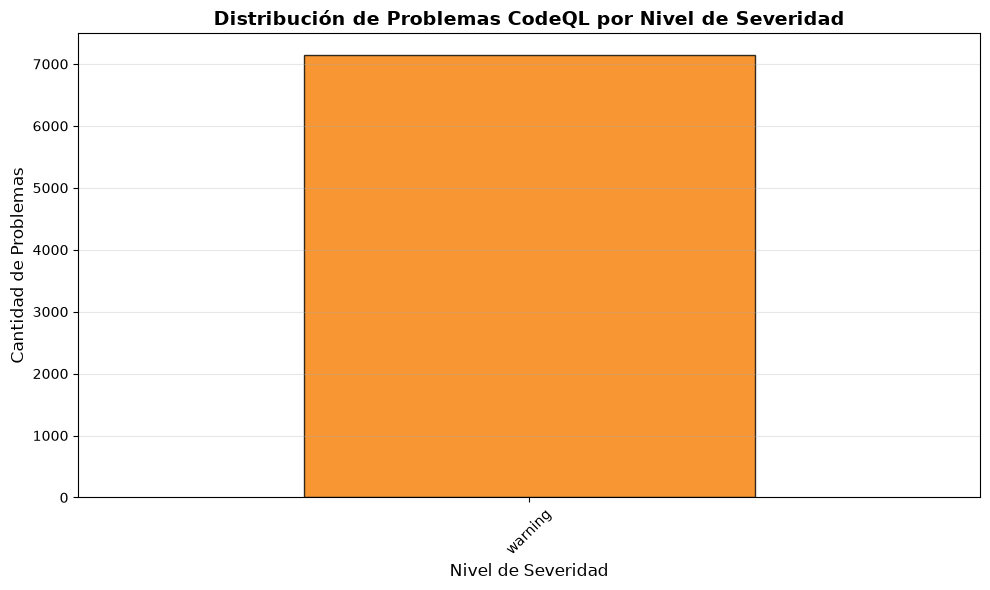

In [18]:
# Gráfico: Distribución por severidad
if len(df_codeql) > 0:
    fig, ax = plt.subplots(figsize=(10, 6))

    stats_severity = df_codeql['level'].value_counts(
    ).sort_index(ascending=False)

    colores = {'error': '#d32f2f', 'warning': '#f57c00', 'note': '#7cb342'}
    color_list = [colores.get(nivel, '#757575')
                  for nivel in stats_severity.index]

    stats_severity.plot(kind='bar', ax=ax, color=color_list,
                        edgecolor='black', alpha=0.8)

    ax.set_title('Distribución de Problemas CodeQL por Nivel de Severidad',
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Nivel de Severidad', fontsize=12)
    ax.set_ylabel('Cantidad de Problemas', fontsize=12)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("No hay datos disponibles para graficar")

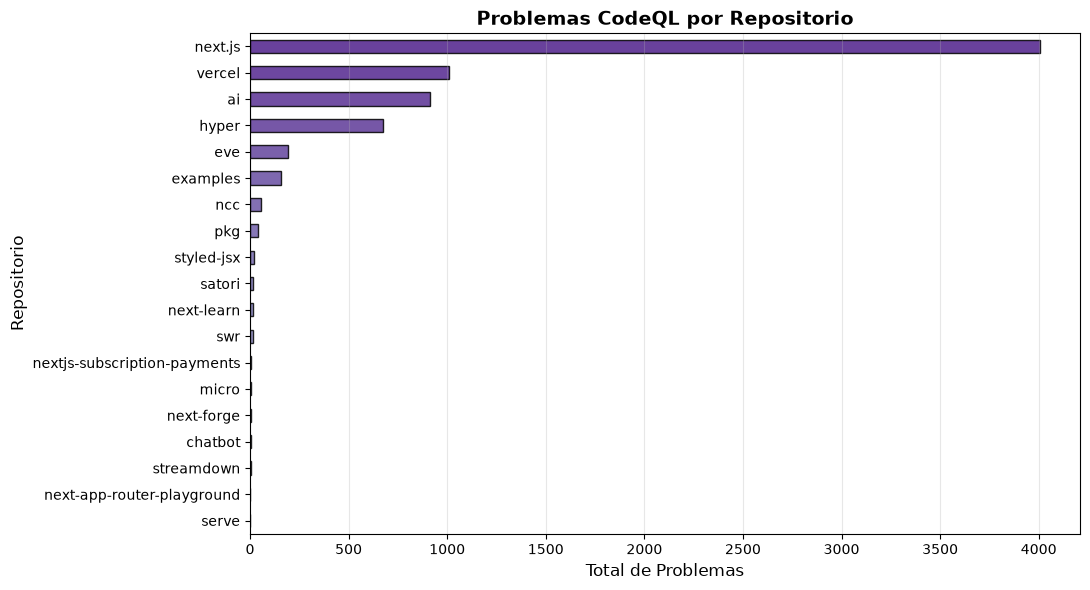

Datos por repositorio exportados a: /Users/mgci/Universidad/Semestre-8/Ciberseguridad/Proyecto-Ciberseguridad/results/codeql-analisis/estadisticas-repo.json


In [25]:
# Gráfico: Problemas por repositorio (CodeQL)
if len(df_codeql) > 0:
    fig, ax = plt.subplots(figsize=(11, 6))

    issues_por_repo_series = df_codeql['repo'].value_counts().sort_values(ascending=True)

    colores_gradiente = plt.cm.Purples(np.linspace(0.4, 0.9, len(issues_por_repo_series)))

    issues_por_repo_series.plot(
        kind='barh', ax=ax, color=colores_gradiente, edgecolor='black', alpha=0.85
    )

    ax.set_title('Problemas CodeQL por Repositorio', fontsize=14, fontweight='bold')
    ax.set_xlabel('Total de Problemas', fontsize=12)
    ax.set_ylabel('Repositorio', fontsize=12)
    ax.grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()

    df_repo_export = df_codeql['repo'].value_counts().reset_index()
    df_repo_export.columns = ['repo', 'count']

    output_repo_path = RESULTS_FOLDER / "codeql-analisis" / "estadisticas-repo.json"
    df_repo_export.to_json(output_repo_path, orient='records', indent=4)
    print(f"Datos por repositorio exportados a: {output_repo_path}")

else:
    print("No hay datos disponibles para graficar ni exportar")

En el gráfico se observa que el repositorio que presenta la mayor cantidad corresponde a “next.js” con casi 4000 vulnerabilidades, seguido por “vercel” que cuenta con aproximadamente 1000.

In [26]:
# Top 5 reglas más comunes
if len(df_codeql) > 0:
    top_rules = df_codeql['rule_id'].value_counts().head(5)

    print("\nTop 5 Reglas de Seguridad Más Frecuentes:")
    print("=" * 70)
    for idx, (rule, count) in enumerate(top_rules.items(), 1):
        porcentaje = (count / len(df_codeql)) * 100
        print(f"{idx:2d}. {rule:40s} {count:3d} ({porcentaje:5.1f}%)")

    df_rules_export = top_rules.reset_index()
    df_rules_export.columns = ['rule_id', 'count']

    output_rules_path = RESULTS_FOLDER / "codeql-analisis" / "estadisticas-reglas.json"
    df_rules_export.to_json(output_rules_path, orient='records', indent=4)
    print(f"\nDatos de reglas exportados a: {output_rules_path}")

else:
    print("No hay datos disponibles")


Top 5 Reglas de Seguridad Más Frecuentes:
 1. js/unused-local-variable                 2043 ( 28.6%)
 2. js/useless-assignment-to-local           612 (  8.6%)
 3. js/useless-expression                    567 (  7.9%)
 4. js/insecure-temporary-file               529 (  7.4%)
 5. js/superfluous-trailing-arguments        406 (  5.7%)

Datos de reglas exportados a: /Users/mgci/Universidad/Semestre-8/Ciberseguridad/Proyecto-Ciberseguridad/results/codeql-analisis/estadisticas-reglas.json


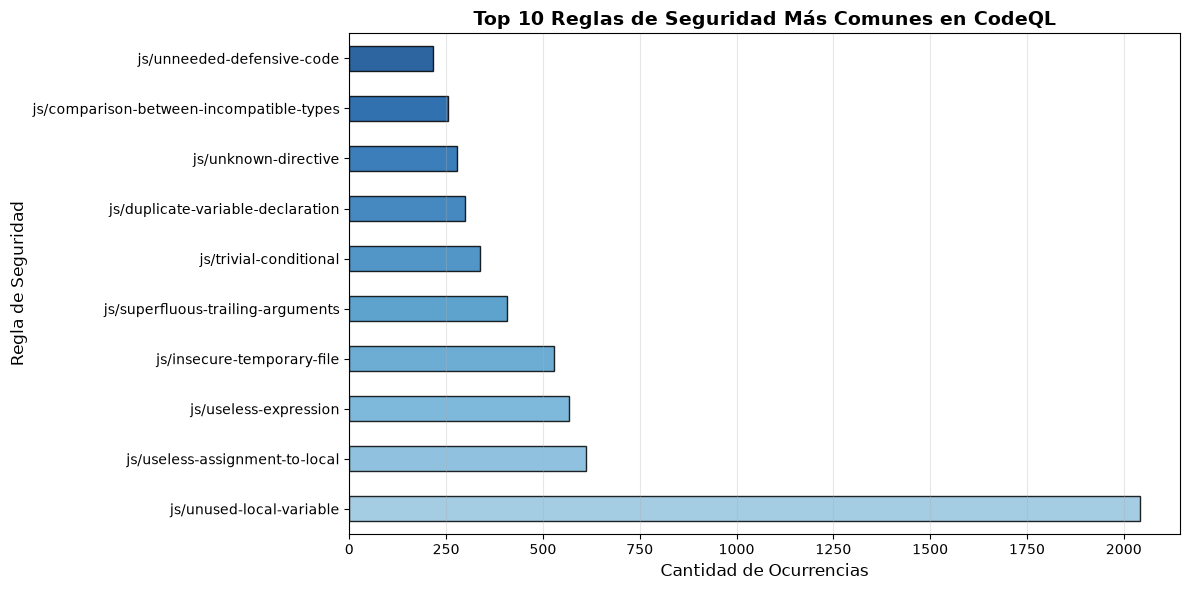

In [27]:
# Gráfico: Top 10 reglas más comunes
if len(df_codeql) > 0:
    fig, ax = plt.subplots(figsize=(12, 6))

    top_rules = df_codeql['rule_id'].value_counts().head(10)

    colores_gradiente = plt.cm.Blues(np.linspace(0.4, 0.9, len(top_rules)))

    top_rules.plot(kind='barh', ax=ax, color=colores_gradiente,
                   edgecolor='black', alpha=0.85)

    ax.set_title('Top 10 Reglas de Seguridad Más Comunes en CodeQL',
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Cantidad de Ocurrencias', fontsize=12)
    ax.set_ylabel('Regla de Seguridad', fontsize=12)
    ax.grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("No hay datos disponibles para graficar")

A continuación se mencionan los 5 problemas más comunes del código fuente:
1. **js/unused-local-variable**: Corresponde a un problema en el cual se crean variables locales las cuales no son utilizadas en ningún momento del programa lo que puede causar problemas de rendimiento. Esto puede llegar a ser síntoma de un error causado en el programa como una refactorización incompleta.

2. **js/useless-assignment-to-local**: Consiste en una variable a la cual se le asigna un valor, pero este nunca es leído posteriormente. Esto puede ser debido a que el valor es sobreescrito antes de ser leído, que la asignación no tiene efecto, un error lógico en el código o código faltante.

3. **js/useless-expression**: Useless expression hace referencia a una expresión que no tienen ningún efecto en el código, como producir un output o cambiar valores, ocurriendo en un contexto donde el valor es posiblemente ignorado, indicando una posible falta de código o un bug latente.

4. **js/insecure-temporary-file**: La creación de archivos temporales sin una librería especializada permite que otros usuarios en el sistema puedan acceder al contenido, por tanto, se recomienda la utilización de una librería especializada para evitar fallos.

5. **js/superfluous-trailing-arguments**: Superfluous trailing arguments corresponde a llamadas a funciones donde se pasan más argumentos de los que son declarados, por lo que los argumentos adicionales sólo pueden ser accedidos mediante el objeto arguments, así que estos quedan inutilizables si la función no contiene ni usa el objeto. Esto puede provocar una refactorización incompleta o malentendidos del funcionamiento.


In [28]:
# 5 reglas mas comunes por repositorio
if len(df_codeql) > 0:
    reglas_por_repo = df_codeql.groupby('repo')['rule_id'].value_counts().unstack(fill_value=0)
 
    print("\nTop 5 Reglas de Seguridad Más Comunes por Repositorio:")
    print("=" * 80)
    
    export_data = []

    for repo in reglas_por_repo.index:
        print(f"{repo:30s}")
        print("-" * 80)

        top_rules = reglas_por_repo.loc[repo].sort_values(ascending=False).head(5)
        rules_list = []
        
        for rule, count in top_rules.items():
            if count > 0:
                porcentaje = (count / df_codeql[df_codeql['repo'] == repo].shape[0]) * 100
                print(f"   - {rule:40s} {count:3d} ({porcentaje:5.1f}%)")
                
                rules_list.append({
                    "rule_id": rule, 
                    "count": int(count),
                    "percentage": round(porcentaje, 1)
                })
        print()
        
        if rules_list:
            export_data.append({
                "repo": repo,
                "rules": rules_list
            })
            
    output_repo_rules_path = RESULTS_FOLDER / "codeql-analisis" / "estadisticas-repo-reglas.json"
    with open(output_repo_rules_path, 'w', encoding='utf-8') as f:
        json.dump(export_data, f, indent=4)
        
    print(f"Datos anidados exportados a: {output_repo_rules_path}")

else:
    print("No hay datos disponibles")


Top 5 Reglas de Seguridad Más Comunes por Repositorio:
ai                            
--------------------------------------------------------------------------------
   - js/unused-local-variable                 505 ( 55.4%)
   - js/unknown-directive                     114 ( 12.5%)
   - js/useless-expression                     54 (  5.9%)
   - js/regex/missing-regexp-anchor            33 (  3.6%)
   - js/log-injection                          25 (  2.7%)

chatbot                       
--------------------------------------------------------------------------------
   - js/insecure-randomness                     2 ( 50.0%)
   - js/trivial-conditional                     1 ( 25.0%)
   - js/unused-local-variable                   1 ( 25.0%)

eve                           
--------------------------------------------------------------------------------
   - js/unknown-directive                     140 ( 72.2%)
   - js/file-system-race                        9 (  4.6%)
   - js/unused-l

In [29]:
# Top 5 reglas en el repositorio con más problemass
if len(df_codeql) > 0:
    repo_mas_problemas = df_codeql['repo'].value_counts().idxmax()
    problemas_repo_mas_problemas = df_codeql[df_codeql['repo'] == repo_mas_problemas]
    
    total_repo = len(problemas_repo_mas_problemas)
    total_general = len(df_codeql)
    porcentaje_total = (total_repo / total_general) * 100

    print(f"\nRepositorio con más problemas: {repo_mas_problemas}")
    print(f"Total de problemas: {total_repo}, un {porcentaje_total:.1f}% del total")
    print("\nTop 5 Reglas de Seguridad Más Frecuentes en este Repositorio:")
    print("=" * 70)
    
    top_rules_repo = problemas_repo_mas_problemas['rule_id'].value_counts().head(5)
    
    reglas_list = []
    for idx, (rule, count) in enumerate(top_rules_repo.items(), 1):
        porcentaje_regla = (count / total_repo) * 100
        print(f"{idx:2d}. {rule:40s} {count:3d} ({porcentaje_regla:5.1f}%)")
        
        reglas_list.append({
            "rule_id": rule,
            "count": int(count),
            "percentage": round(porcentaje_regla, 1)
        })

    export_peor_repo = {
        "repo_name": repo_mas_problemas,
        "total_issues": int(total_repo),
        "percentage_of_total": round(porcentaje_total, 1),
        "top_rules": reglas_list
    }

    output_peor_repo_path = RESULTS_FOLDER / "codeql-analisis" / "estadisticas-peor-repo.json"
    with open(output_peor_repo_path, 'w', encoding='utf-8') as f:
        json.dump(export_peor_repo, f, indent=4)
        
    print(f"\nDatos del peor repo exportados a: {output_peor_repo_path}")

else:
    print("No hay datos disponibles")


Repositorio con más problemas: next.js
Total de problemas: 4009, un 56.2% del total

Top 5 Reglas de Seguridad Más Frecuentes en este Repositorio:
 1. js/unused-local-variable                 1086 ( 27.1%)
 2. js/useless-assignment-to-local           505 ( 12.6%)
 3. js/useless-expression                    495 ( 12.3%)
 4. js/superfluous-trailing-arguments        391 (  9.8%)
 5. js/trivial-conditional                   278 (  6.9%)

Datos del peor repo exportados a: /Users/mgci/Universidad/Semestre-8/Ciberseguridad/Proyecto-Ciberseguridad/results/codeql-analisis/estadisticas-peor-repo.json


In [30]:
# Top 3 archivos con más vulnerabilidades por repositorio
if len(df_codeql) > 0:
    print("\nTop 3 Archivos con Más Vulnerabilidades por Repositorio:")
    print("=" * 80)
    
    export_archivos = []
    
    for repo in df_codeql['repo'].unique():
        print(f"{repo:30s}")
        print("-" * 80)

        repo_data = df_codeql[df_codeql['repo'] == repo]
        repo_total_issues = repo_data.shape[0]
        
        top_files = repo_data['file'].value_counts().head(3)
        archivos_list = []
        
        for idx, (file, count) in enumerate(top_files.items(), 1):
            porcentaje = (count / repo_total_issues) * 100
            print(f"   - {file:50s} {count:3d} ({porcentaje:5.1f}%)")
            
            archivos_list.append({
                "file_path": file,
                "count": int(count),
                "percentage": round(porcentaje, 1)
            })
        print()
        
        if archivos_list:
            export_archivos.append({
                "repo": repo,
                "files": archivos_list
            })

    output_archivos_path = RESULTS_FOLDER / "codeql-analisis" / "estadisticas-repo-archivos.json"
    with open(output_archivos_path, 'w', encoding='utf-8') as f:
        json.dump(export_archivos, f, indent=4)
        
    print(f"Datos de archivos exportados a: {output_archivos_path}")

else:
    print("No hay datos disponibles")


Top 3 Archivos con Más Vulnerabilidades por Repositorio:
ai                            
--------------------------------------------------------------------------------
   - packages/provider-utils/src/is-url-supported.test.ts  29 (  3.2%)
   - packages/workflow/src/test/agent-e2e-workflows.ts   27 (  3.0%)
   - packages/codemod/src/test/__testfixtures__/replace-usechat-input-with-state.output.ts  13 (  1.4%)

chatbot                       
--------------------------------------------------------------------------------
   - components/chat/shell.tsx                            1 ( 25.0%)
   - lib/db/utils.ts                                      1 ( 25.0%)
   - components/chat/version-footer.tsx                   1 ( 25.0%)

eve                           
--------------------------------------------------------------------------------
   - packages/eve/src/internal/testing/workflow-tool-fixtures.ts  17 (  8.8%)
   - packages/eve/src/execution/tasks/child/steps.ts      9 (  4.6%)
   - p

## Análisis Grype: Vulnerabilidades en Dependencias

In [31]:
# Cargar todos los análisis Grype
grype_files = sorted(RESULTS_FOLDER.glob("*-grype.json"))

print(f"\nBuscando archivos Grype en: {RESULTS_FOLDER}")
print(f"✓ Archivos encontrados: {len(grype_files)}\n")

# Consolidar en un solo DataFrame
data_grype = []

for archivo in grype_files:
    with open(archivo, 'r', encoding='utf-8') as f:
        contenido = json.load(f)

    repo_name = archivo.stem.replace('-grype', '')
    vulns = contenido.get('vulnerabilities', [])

    for vuln in vulns:
        vuln['repo'] = repo_name
        data_grype.append(vuln)

df_grype = pd.DataFrame(data_grype)

print(f"Total de vulnerabilidades cargadas: {len(df_grype)}")
print(
    f"Repositorios únicos: {df_grype['repo'].nunique() if len(df_grype) > 0 else 0}\n")


Buscando archivos Grype en: /Users/mgci/Universidad/Semestre-8/Ciberseguridad/Proyecto-Ciberseguridad/results
✓ Archivos encontrados: 25

Total de vulnerabilidades cargadas: 32257
Repositorios únicos: 25



In [33]:
# Estadísticas por severidad (con rangos CVSS)
if len(df_grype) > 0:
    stats_severity = df_grype['vuln_severity'].value_counts()

    cvss_ranges = {
        'critical': '9.0 - 10.0',
        'high': '7.0 - 8.9',
        'medium': '4.0 - 6.9',
        'low': '0.0 - 3.9'
    }

    print("Vulnerabilidades por Nivel de Severidad CVSS:")
    print("=" * 60)
    print(f"{'Severidad':<12} {'Cantidad':<10} {'Rango CVSS':<15} {'%':<8}")
    print("=" * 60)

    export_grype_sev = []

    for severidad in ['critical', 'high', 'medium', 'low']:
        cantidad = int(stats_severity.get(severidad, 0))
        porcentaje = (cantidad / len(df_grype) * 100) if len(df_grype) > 0 else 0
        rango = cvss_ranges.get(severidad, 'N/A')
        print(f"{severidad:<10} {cantidad:<10} {rango:<15} {porcentaje:>6.1f}%")

        export_grype_sev.append({
            "level": severidad,
            "count": cantidad,
            "cvss": rango,
            "percentage": round(porcentaje, 1)
        })

    print("=" * 60)
    print(f"Total general: {len(df_grype)} vulnerabilidades encontradas")

    output_grype_sev_path = RESULTS_FOLDER / "grype-analisis" /"grype-severidad.json"
    output_grype_sev_path.parent.mkdir(parents=True, exist_ok=True)
    
    with open(output_grype_sev_path, 'w', encoding='utf-8') as f:
        json.dump(export_grype_sev, f, indent=4)
        
    print(f"\nDatos de severidad Grype exportados a: {output_grype_sev_path}")

else:
    print("No hay datos de Grype disponibles")

Vulnerabilidades por Nivel de Severidad CVSS:
Severidad    Cantidad   Rango CVSS      %       
critical   1479       9.0 - 10.0         4.6%
high       13672      7.0 - 8.9         42.4%
medium     14210      4.0 - 6.9         44.1%
low        2896       0.0 - 3.9          9.0%
Total general: 32257 vulnerabilidades encontradas

Datos de severidad Grype exportados a: /Users/mgci/Universidad/Semestre-8/Ciberseguridad/Proyecto-Ciberseguridad/results/grype-analisis/grype-severidad.json


Respecto al análisis con Grype realizado,  se encontraron 32.257 vulnerabilidades de componentes, de las cuales el 4,6% fueron críticas, 42,4% fueron altas, el 44,1% son medias y el 9,0% son bajas. 

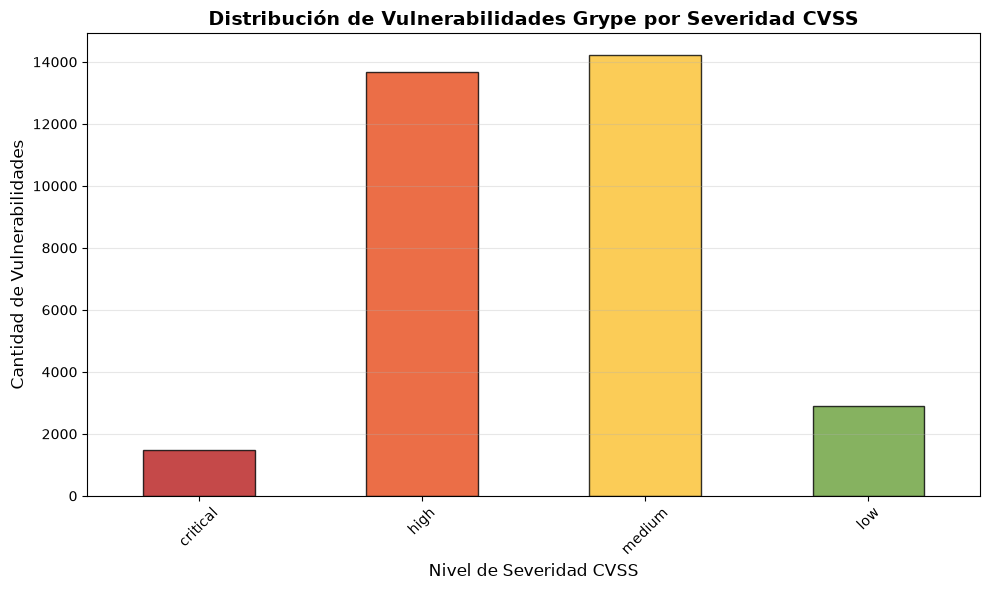

In [34]:
# Gráfico: Distribución por severidad
if len(df_grype) > 0:
    fig, ax = plt.subplots(figsize=(10, 6))

    severidad_order = ['critical', 'high', 'medium', 'low']
    stats_severity = df_grype['vuln_severity'].value_counts()
    stats_severity = stats_severity.reindex(
        [s for s in severidad_order if s in stats_severity.index])

    colores = {'critical': '#b71c1c', 'high': '#e64a19',
               'medium': '#fbc02d', 'low': '#689f38'}
    color_list = [colores.get(nivel, '#757575')
                  for nivel in stats_severity.index]

    stats_severity.plot(kind='bar', ax=ax, color=color_list,
                        edgecolor='black', alpha=0.8)

    ax.set_title('Distribución de Vulnerabilidades Grype por Severidad CVSS',
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Nivel de Severidad CVSS', fontsize=12)
    ax.set_ylabel('Cantidad de Vulnerabilidades', fontsize=12)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("No hay datos disponibles para graficar")

La distribución del nivel de severidad de las vulnerabilidades de dependencias es altamente preocupante, ya que, si bien la mayor cantidad se encuentra en "medium", el rango numérico de la severidad "high" es menor. Esto indica un riesgo muy grande para la organización, aumentando su probabilidad de ser víctimas (nuevamente) de un ciberataque.

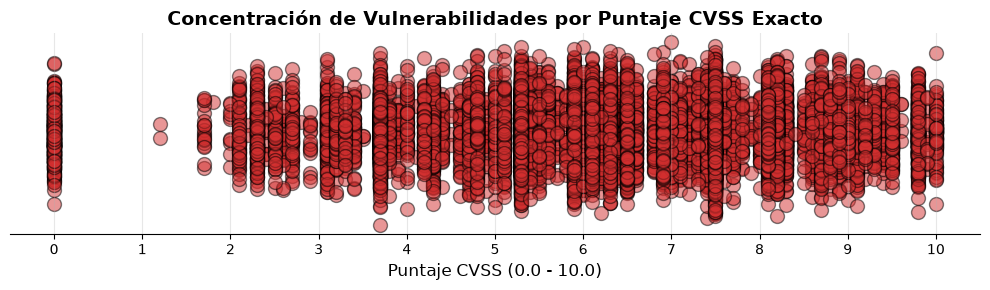

Datos de dispersión CVSS exportados a: /Users/mgci/Universidad/Semestre-8/Ciberseguridad/Proyecto-Ciberseguridad/results/grype-analisis/grype-cvss.json


In [35]:
# Gráfico: Dispersión de puntajes CVSS (si están disponibles)
if len(df_grype) > 0 and 'cvss_score' in df_grype.columns:
    fig, ax = plt.subplots(figsize=(10, 3))

    df_cvss = df_grype[df_grype['cvss_score'].apply(lambda x: isinstance(x, (int, float)))].copy()

    if not df_cvss.empty:
        df_cvss['cvss_score'] = pd.to_numeric(df_cvss['cvss_score'], errors='coerce')

        x_vals = df_cvss['cvss_score']
        y_vals = np.ones(len(x_vals)) + np.random.normal(0, 0.05, len(x_vals))

        ax.scatter(x_vals, y_vals, color='#d32f2f', alpha=0.5, edgecolor='black', s=100)

        ax.set_title('Concentración de Vulnerabilidades por Puntaje CVSS Exacto', fontsize=14, fontweight='bold')
        ax.set_xlabel('Puntaje CVSS (0.0 - 10.0)', fontsize=12)
        
        ax.set_xlim(-0.5, 10.5)
        ax.set_xticks(range(11))
        ax.set_yticks([])
        ax.spines['left'].set_visible(False)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        ax.grid(axis='x', alpha=0.3)

        plt.tight_layout()
        plt.show()
        df_cvss_clean = df_cvss.dropna(subset=['cvss_score'])
        
        export_cvss = df_cvss_clean[['package_name', 'cvss_score', 'vuln_severity']].to_dict(orient='records')
        
        output_grype_cvss_path = RESULTS_FOLDER / "grype-analisis" / "grype-cvss.json"
        with open(output_grype_cvss_path, 'w', encoding='utf-8') as f:
            json.dump(export_cvss, f, indent=4)
            
        print(f"Datos de dispersión CVSS exportados a: {output_grype_cvss_path}")

    else:
        print("No hay puntajes CVSS válidos para graficar ni exportar")
else:
    print("No hay datos de CVSS disponibles")

Se puede apreciar que la dispersión se encuentra concentrada entre los puntos 5 y 7,5, dando a interpretar una severidad mediana-alta de puntos de riesgo de los cuales los atacantes se pueden aprovechar.

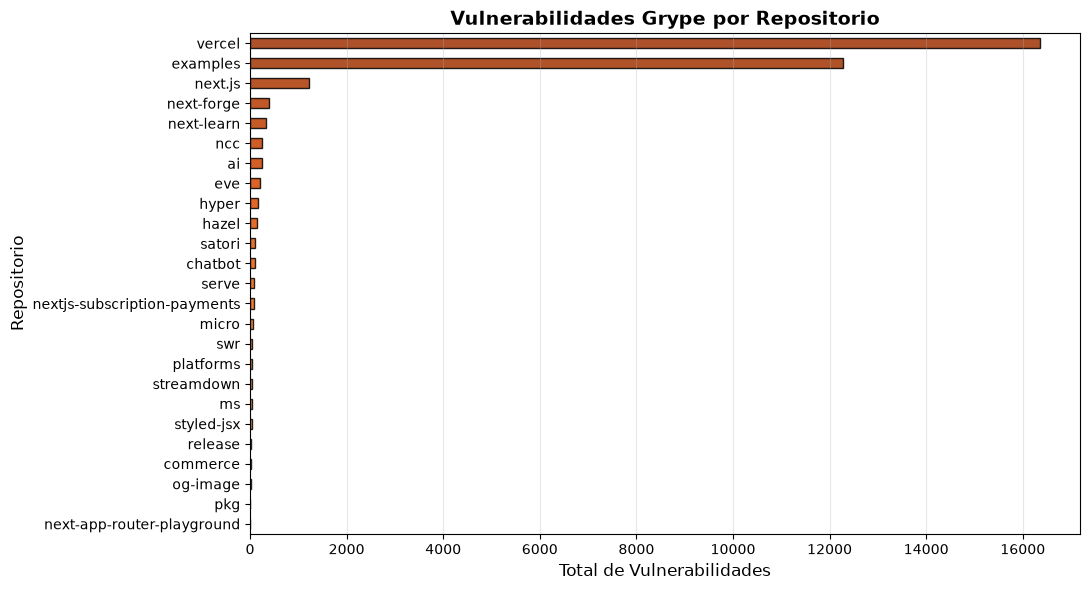

Datos de Grype por repositorio exportados a: /Users/mgci/Universidad/Semestre-8/Ciberseguridad/Proyecto-Ciberseguridad/results/grype-analisis/grype-repo.json


In [36]:
# Gráfico: Vulnerabilidades por repositorio (Grype)
if len(df_grype) > 0:
    fig, ax = plt.subplots(figsize=(11, 6))

    vulns_por_repo = df_grype['repo'].value_counts().sort_values(ascending=True)

    colores_gradiente = plt.cm.Oranges(np.linspace(0.4, 0.9, len(vulns_por_repo)))

    vulns_por_repo.plot(kind='barh', ax=ax,
                        color=colores_gradiente, edgecolor='black', alpha=0.85)

    ax.set_title('Vulnerabilidades Grype por Repositorio',
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Total de Vulnerabilidades', fontsize=12)
    ax.set_ylabel('Repositorio', fontsize=12)
    ax.grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()
    
    df_grype_repo_export = df_grype['repo'].value_counts().reset_index()
    df_grype_repo_export.columns = ['repo', 'count']

    output_grype_repo_path = RESULTS_FOLDER / "grype-analisis" / "grype-repo.json"
    df_grype_repo_export.to_json(output_grype_repo_path, orient='records', indent=4)
    print(f"Datos de Grype por repositorio exportados a: {output_grype_repo_path}")

else:
    print("No hay datos disponibles para graficar")

Se puede observar en el gráfico que los repositorios *vercel* y *examples* tienen una cantidad significativamente mayor de vulnerabilidades de componentes, abordando cifras de más de 16.000 y más de 12.000, respectivamente.

In [37]:
# Top 5 paquetes más vulnerables
if len(df_grype) > 0:
    top_packages = df_grype['package_name'].value_counts().head(10)

    print("\nTop 10 Paquetes con Más Vulnerabilidades:")
    print("=" * 80)
    print(f"{'Paquete':<30} {'Vulns':<10} {'Vers. Actual':<15} {'Fix?':<8}")
    print("=" * 80)

    for pkg_name in top_packages.index:
        pkg_data = df_grype[df_grype['package_name'] == pkg_name].iloc[0]
        cantidad = top_packages[pkg_name]
        version = pkg_data.get('current_version', 'N/A')
        fix = pkg_data.get('fix_version', 'N/A')
        fix_status = "✓ Sí" if fix != 'N/A' else "✗ No"

        print(f"{pkg_name:<30} {cantidad:<10} {str(version):<15} {fix_status:<8}")

else:
    print("No hay datos disponibles")


Top 10 Paquetes con Más Vulnerabilidades:
Paquete                        Vulns      Vers. Actual    Fix?    
next                           5031       16.2.10         ✗ No    
hono                           1838       4.12.25         ✗ No    
postcss                        1801       8.5.12          ✗ No    
brace-expansion                1309       1.1.14          ✗ No    
axios                          1228       1.13.6          ✗ No    
js-yaml                        1165       3.14.2          ✗ No    
nanoid                         1079       3.3.12          ✗ No    
minimatch                      933        10.1.1          ✗ No    
tar                            877        7.5.19          ✗ No    
undici                         752        5.29.0          ✗ No    


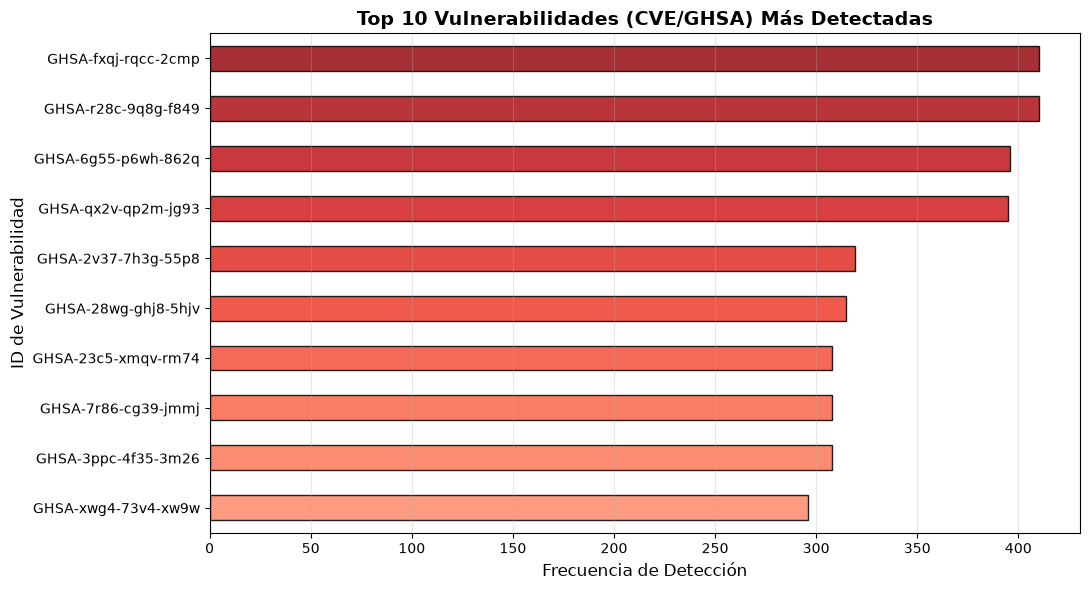


Top 10 Vulnerabilidades (Detalle en Consola):
ID: GHSA-r28c-9q8g-f849       | Detecciones: 410 | Severidad: HIGH | Descripción: PostCSS: Path Traversal in Previous Source Map Auto-Loading (sourceMappingURL) leads to Arbitrary .map File Disclosure
ID: GHSA-fxqj-rqcc-2cmp       | Detecciones: 410 | Severidad: MEDIUM | Descripción: PostCSS: incomplete fix of GHSA-6g55-p6wh-862q — attacker-controlled sourceMappingURL reads arbitrary .map files when `from` is unset
ID: GHSA-6g55-p6wh-862q       | Detecciones: 396 | Severidad: HIGH | Descripción: PostCSS: Arbitrary file read and information disclosure via attacker-controlled sourceMappingURL in CSS comments
ID: GHSA-qx2v-qp2m-jg93       | Detecciones: 395 | Severidad: MEDIUM | Descripción: PostCSS has XSS via Unescaped </style> in its CSS Stringify Output
ID: GHSA-2v37-7h3g-55p8       | Detecciones: 319 | Severidad: MEDIUM | Descripción: nanoid: custom generators can loop indefinitely when size is zero
ID: GHSA-28wg-ghj8-5hjv       | Detecc

In [38]:
# Verificar que el DataFrame tenga datos
if len(df_grype) > 0:
    id_col = 'vuln_id' if 'vuln_id' in df_grype.columns else 'vulnerability_id'

    if id_col in df_grype.columns:
        fig, ax = plt.subplots(figsize=(11, 6))

        top_10_vulns = df_grype[id_col].value_counts().head(10)

        top_10_sorted = top_10_vulns.sort_values(ascending=True)

        colores = plt.cm.Reds(np.linspace(0.4, 0.9, len(top_10_sorted)))
        
        top_10_sorted.plot(kind='barh', ax=ax, color=colores, edgecolor='black', alpha=0.85)

        ax.set_title('Top 10 Vulnerabilidades (CVE/GHSA) Más Detectadas', fontsize=14, fontweight='bold')
        ax.set_xlabel('Frecuencia de Detección', fontsize=12)
        ax.set_ylabel('ID de Vulnerabilidad', fontsize=12)
        ax.grid(axis='x', alpha=0.3)

        plt.tight_layout()
        plt.show()

        print("\nTop 10 Vulnerabilidades (Detalle en Consola):")
        print("=" * 60)
        
        export_top_10 = []

        for vuln_id, count in top_10_vulns.items():
            vuln_data = df_grype[df_grype[id_col] == vuln_id].iloc[0]
            message = vuln_data.get('message', 'Sin descripción')
            severity = vuln_data.get('vuln_severity', 'N/A').upper()
            print(f"ID: {vuln_id:25s} | Detecciones: {count} | Severidad: {severity} | Descripción: {message}")
            export_top_10.append({
                "vuln_id": str(vuln_id),
                "count": int(count)
            })

        output_top10_path = RESULTS_FOLDER / "grype-analisis" / "grype-top-10-vulns.json"
        
        with open(output_top10_path, 'w', encoding='utf-8') as f:
            json.dump(export_top_10, f, indent=4)
            
        print(f"\nDatos exportados para la web en: {output_top10_path}")
        
    else:
        print("No se encontró la columna de IDs de vulnerabilidad ('vuln_id') en el DataFrame.")
else:
    print("No hay datos de Grype disponibles para graficar.")

In [39]:
# Top 3 paquetes más vulnerables
if len(df_grype) > 0:
    top_packages = df_grype['package_name'].value_counts().head(3)

    print("\nTop 3 Paquetes con Más Vulnerabilidades:")
    print("=" * 80)
    print(f"{'Paquete':<30} {'Vulns':<10} {'Vers. Actual':<15} {'Fix?':<8}")
    print("=" * 80)

    export_top_pkgs = []

    for pkg_name in top_packages.index:
        pkg_data = df_grype[df_grype['package_name'] == pkg_name].iloc[0]
        cantidad = int(top_packages[pkg_name])
        version = str(pkg_data.get('current_version', 'N/A'))
        fix = str(pkg_data.get('fix_version', 'N/A'))
        has_fix = fix != 'N/A'
        fix_status = "✓ Sí" if has_fix else "✗ No"

        print(f"{pkg_name:<30} {cantidad:<10} {version:<15} {fix_status:<8}")

        export_top_pkgs.append({
            "package_name": pkg_name,
            "count": cantidad,
            "current_version": version,
            "has_fix": has_fix,
            "fix_version": fix
        })

    print("=" * 80)

    output_grype_pkgs_path = RESULTS_FOLDER / "grype-analisis" / "grype-top-paquetes.json"
    with open(output_grype_pkgs_path, 'w', encoding='utf-8') as f:
        json.dump(export_top_pkgs, f, indent=4)
        
    print(f"Datos del Top 3 de paquetes exportados a: {output_grype_pkgs_path}")

else:
    print("No hay datos disponibles")


Top 3 Paquetes con Más Vulnerabilidades:
Paquete                        Vulns      Vers. Actual    Fix?    
next                           5031       16.2.10         ✗ No    
hono                           1838       4.12.25         ✗ No    
postcss                        1801       8.5.12          ✗ No    
Datos del Top 3 de paquetes exportados a: /Users/mgci/Universidad/Semestre-8/Ciberseguridad/Proyecto-Ciberseguridad/results/grype-analisis/grype-top-paquetes.json


In [41]:
paquetes = ["next", "hono", "postcss"]

for pkg_name in paquetes:
    print(f"\nPrimera vulnerabilidad encontrada para el paquete '{pkg_name}':")
    print("=" * 80)

    pkg_vulns = df_grype[df_grype['package_name'] == pkg_name]
    
    if not pkg_vulns.empty:
        row = pkg_vulns.iloc[0]
        
        vuln_id = row.get('vuln_id', row.get('vulnerability_id', 'N/A'))
        severity = row.get('vuln_severity', 'N/A')
        current_version = row.get('current_version', 'N/A')
        fix_version = row.get('fix_version', 'N/A')
        message = row.get('message', 'Sin descripción detallada disponible.')
        repo = row.get('repo', 'N/A') 

        print(f"- Repo: {repo} | ID: {vuln_id}, Severidad: {severity}, Versión Actual: {current_version}")
        print(f"  Detalle: {message}")
    else:
        print(f"No se encontraron vulnerabilidades para '{pkg_name}'")


Primera vulnerabilidad encontrada para el paquete 'next':
- Repo: chatbot | ID: GHSA-p293-qw3h-jr36, Severidad: critical, Versión Actual: 16.2.10
  Detalle: Next.js: Unauthenticated Remote Code Execution on windows-hosted servers

Primera vulnerabilidad encontrada para el paquete 'hono':
- Repo: ai | ID: GHSA-8j4g-w8fx-2239, Severidad: medium, Versión Actual: 4.12.25
  Detalle: Hono: ReDoS in CORS middleware via Access-Control-Request-Headers

Primera vulnerabilidad encontrada para el paquete 'postcss':
- Repo: ai | ID: GHSA-r28c-9q8g-f849, Severidad: high, Versión Actual: 8.5.12
  Detalle: PostCSS: Path Traversal in Previous Source Map Auto-Loading (sourceMappingURL) leads to Arbitrary .map File Disclosure


A continuación se mencionan las 3 dependencias con más vulnerabilidades encontradas en conjunto con algunas específicas:
1. **next**: Permite crear aplicaciones web full-stack extendiendo las últimas características de *React* e integrando potentes herramientas de *JavaScript* basadas en *Rust* para lograr compilaciones más rápidas. Una de las vulnerabilidades que presenta esta dependencia tiene el código de [GHSA-p293-qw3h-jr36](https://github.com/vercel/next.js/security/advisories/GHSA-p293-qw3h-jr36) de severidad CVSS 9,0. Una vulnerabilidad en las aplicaciones que usan Pages y el router App sin Cache Component puede conducir a la ejecución remota de código cuando el servidor está alojado en máquinas que usan un sistema de archivos Windows, por tanto, se recomienda actualizar la versión para evitarlo.

2. **hono**: Hono es un marco web pequeño, simple y ultrarrápido basado en los estándares web. Funciona en cualquier tiempo de ejecución de JavaScript. Una de las vulnerabilidades que presenta esta dependencia tiene el código de [GHSA-8j4g-w8fx-2239](https://github.com/advisories/GHSA-8j4g-w8fx-2239) de severidad CVSS 5,3. El middleware CORS incorporado (hono/cors) analiza el encabezado de solicitud Access-Control-Request-Headers controlado por el atacante durante una solicitud de prevuelo (OPCIONES) utilizando una expresión regular cuyo tiempo de ejecución es cuadrático en la longitud de entrada. Una sola solicitud que lleva una larga ejecución de espacio en blanco puede consumir segundos de CPU, y las solicitudes repetidas pueden hacer que el servicio no responda. Este análisis se ejecuta en la configuración predeterminada.

3. **postcss**: PostCSS es una herramienta para transformar estilos con plugins JS. Estos plugins pueden pelsar su CSS, admitir variables y mixins, transpilar la sintaxis futura de CSS, imágenes en línea y más. Una de las vulnerabilidades que presenta esta dependencia tiene el código de [GHSA-r28c-9q8g-f849](https://github.com/advisories/GHSA-r28c-9q8g-f849) de severidad CVSS 7,5. Esta corresponde a una vulnerabilidad de Divulgación del contenido de archivos .map arbitrarios accesibles a través de la travesía de ruta (o ruta absoluta cuando desde está no establecida) desde el sistema de archivos del proceso. Afecta cualquier aplicación que procese CSS en la que no confíe completamente sin pasar explícitamente el mapa: false. No se requiere autenticación o interacción del usuario más allá de la presentación de texto CSS.

In [42]:
# Mostrar la informacion de las vulnerabilidades del paquete kysely
if len(df_grype) > 0:
    pkg_name = "kysely"
    pkg_vulns = df_grype[df_grype['package_name'] == pkg_name]
    
    export_kysely = []

    if not pkg_vulns.empty:
        print(f"\nVulnerabilidades encontradas para el paquete '{pkg_name}':")
        print("=" * 80)
        for idx, row in pkg_vulns.iterrows():
            vuln_id = row.get('vuln_id', row.get('vulnerability_id', 'N/A'))
            severity = row.get('vuln_severity', 'N/A')
            current_version = row.get('current_version', 'N/A')
            fix_version = row.get('fix_version', 'N/A')
            message = row.get('message', 'Sin descripción detallada disponible.')
            repo = row.get('repo', 'N/A') 
            
            print(f"\n- Repo: {repo} | ID: {vuln_id}, Severidad: {severity}, Versión Actual: {current_version}")
            print(f"  Detalle: {message}")
            
            export_kysely.append({
                "vuln_id": vuln_id,
                "severity": severity,
                "current_version": str(current_version),
                "fix_version": str(fix_version),
                "message": str(message),
                "repo": str(repo)
            })
    else:
        print(f"No se encontraron vulnerabilidades para el paquete '{pkg_name}'")
        
    output_kysely_path = RESULTS_FOLDER / "grype-analisis" / "grype-kysely.json"
    with open(output_kysely_path, 'w', encoding='utf-8') as f:
        json.dump(export_kysely, f, indent=4)
        
    print(f"\nDatos del paquete {pkg_name} exportados a: {output_kysely_path}")

else:
    print("No hay datos disponibles")


Vulnerabilidades encontradas para el paquete 'kysely':

- Repo: chatbot | ID: GHSA-wmrf-hv6w-mr66, Severidad: high, Versión Actual: 0.28.11
  Detalle: SQL Injection via unsanitized JSON path keys when ignoring/silencing compilation errors or using `Kysely<any>`.

- Repo: chatbot | ID: GHSA-8cpq-38p9-67gx, Severidad: high, Versión Actual: 0.28.11
  Detalle: Kysely has a MySQL SQL Injection via Insufficient Backslash Escaping in `sql.lit(string)` usage or similar methods that append string literal values into the compiled SQL strings

- Repo: chatbot | ID: GHSA-pv5w-4p9q-p3v2, Severidad: high, Versión Actual: 0.28.11
  Detalle: Kysely: JSON-path traversal injection via unsanitized path-leg metacharacters in `JSONPathBuilder.key()` / `.at()`

- Repo: examples | ID: GHSA-wmrf-hv6w-mr66, Severidad: high, Versión Actual: 0.26.3
  Detalle: SQL Injection via unsanitized JSON path keys when ignoring/silencing compilation errors or using `Kysely<any>`.

- Repo: examples | ID: GHSA-8cpq-38p9-67g

Al equipo le llamó la atención las vulnerabilidades del componente Kysely dentro de los repositorio de *chatbot* y *examples*, que contenían dos amenazas de posibles inyecciones SQL calificadas con un CVSS de [8,1](https://github.com/advisories/GHSA-8cpq-38p9-67gx) y de [8,2](https://github.com/advisories/GHSA-wmrf-hv6w-mr66), con Vercel aún manteniendo la versión afectada por ambas, a pesar de que la primera ya ha sido corregida en la versión 0.28.14 y la segunda fue corregida en la versión 0.28.12.

In [43]:
# Repositorio con mas problemas en total y con menos, contando grype y codeql juntos.
if len(df_codeql) > 0 and len(df_grype) > 0:
    total_problemas = pd.concat([
        df_codeql.groupby('repo').size().rename('codeql_count'),
        df_grype.groupby('repo').size().rename('grype_count')
    ], axis=1).fillna(0)

    total_problemas['total'] = total_problemas['codeql_count'] + total_problemas['grype_count']

    repo_mas_problemas = total_problemas['total'].idxmax()
    repo_menos_problemas = total_problemas[total_problemas['total'] > 0]['total'].idxmin()

    print(f"\nRepositorio con más problemas (CodeQL + Grype): {repo_mas_problemas} ({int(total_problemas.loc[repo_mas_problemas, 'total'])} problemas)")
    print(f"Repositorio con menos problemas (CodeQL + Grype): {repo_menos_problemas} ({int(total_problemas.loc[repo_menos_problemas, 'total'])} problemas)")
    
    export_global = {
        "max": {
            "repo": repo_mas_problemas,
            "total": int(total_problemas.loc[repo_mas_problemas, 'total']),
            "codeql": int(total_problemas.loc[repo_mas_problemas, 'codeql_count']),
            "grype": int(total_problemas.loc[repo_mas_problemas, 'grype_count'])
        },
        "min": {
            "repo": repo_menos_problemas,
            "total": int(total_problemas.loc[repo_menos_problemas, 'total']),
            "codeql": int(total_problemas.loc[repo_menos_problemas, 'codeql_count']),
            "grype": int(total_problemas.loc[repo_menos_problemas, 'grype_count'])
        }
    }
    
    output_global_path = RESULTS_FOLDER / "grype-analisis" / "resumen-global.json"
    with open(output_global_path, 'w', encoding='utf-8') as f:
        json.dump(export_global, f, indent=4)
        
    print(f"Datos del resumen global exportados a: {output_global_path}")

else:
    print("No hay datos suficientes para determinar repositorios con más/menos problemas")


Repositorio con más problemas (CodeQL + Grype): vercel (17375 problemas)
Repositorio con menos problemas (CodeQL + Grype): next-app-router-playground (7 problemas)
Datos del resumen global exportados a: /Users/mgci/Universidad/Semestre-8/Ciberseguridad/Proyecto-Ciberseguridad/results/grype-analisis/resumen-global.json


## Análisis de CI con CodeQL

In [44]:
# Cargar todos los análisis CodeQL
codeql_files = sorted(RESULTS_FOLDER.glob("*-pipeline.json"))

print(f"\nBuscando archivos CodeQL en: {RESULTS_FOLDER}")
print(f"✓ Archivos encontrados: {len(codeql_files)}\n")

# Consolidar en un solo DataFrame
data_consolidado = []

for archivo in codeql_files:
    with open(archivo, 'r', encoding='utf-8') as f:
        contenido = json.load(f)

    repo_name = archivo.stem.replace('-pipeline', '')
    issues = contenido.get('issues', [])

    for issue in issues:
        issue['repo'] = repo_name
        data_consolidado.append(issue)

df_codeql = pd.DataFrame(data_consolidado)

print(f"Total de problemas cargados: {len(df_codeql)}")
print(
    f"Repositorios únicos: {df_codeql['repo'].nunique() if len(df_codeql) > 0 else 0}\n")


Buscando archivos CodeQL en: /Users/mgci/Universidad/Semestre-8/Ciberseguridad/Proyecto-Ciberseguridad/results
✓ Archivos encontrados: 18

Total de problemas cargados: 118
Repositorios únicos: 17



Respecto al análisis relacionado al CI, de los 25 repositorios incluidos, 17 encontraron problemas, mientras que los 8 restantes no presentaban CI o presentaron errores al procesar sus archivos.

In [46]:
# Estadísticas por severidad
if len(df_codeql) > 0:
    stats_severity = df_codeql['level'].value_counts().sort_index(ascending=False)

    print("Problemas por Nivel de Severidad:")
    print("=" * 50)
    
    export_ci = {
        "total_repos": int(df_codeql['repo'].nunique()),
        "total_issues": len(df_codeql),
        "severities": []
    }

    for nivel, cantidad in stats_severity.items():
        porcentaje = (cantidad / len(df_codeql)) * 100
        print(f"{nivel.upper()}: {cantidad} ({porcentaje:.1f}%)")
        
        export_ci["severities"].append({
            "level": nivel,
            "count": int(cantidad),
            "percentage": round(porcentaje, 1)
        })

    print(f"\nTotal general: {len(df_codeql)} problemas encontrados")
    
    output_ci_path = RESULTS_FOLDER / "ci-analisis" /"ci-severidad.json"
    output_ci_path.parent.mkdir(parents=True, exist_ok=True)
    with open(output_ci_path, 'w', encoding='utf-8') as f:
        json.dump(export_ci, f, indent=4)
        
    print(f"\nDatos de CI exportados a: {output_ci_path}")

else:
    print("No hay datos de CI/Pipeline disponibles")

Problemas por Nivel de Severidad:

Total general: 118 problemas encontrados

Datos de CI exportados a: /Users/mgci/Universidad/Semestre-8/Ciberseguridad/Proyecto-Ciberseguridad/results/ci-analisis/ci-severidad.json


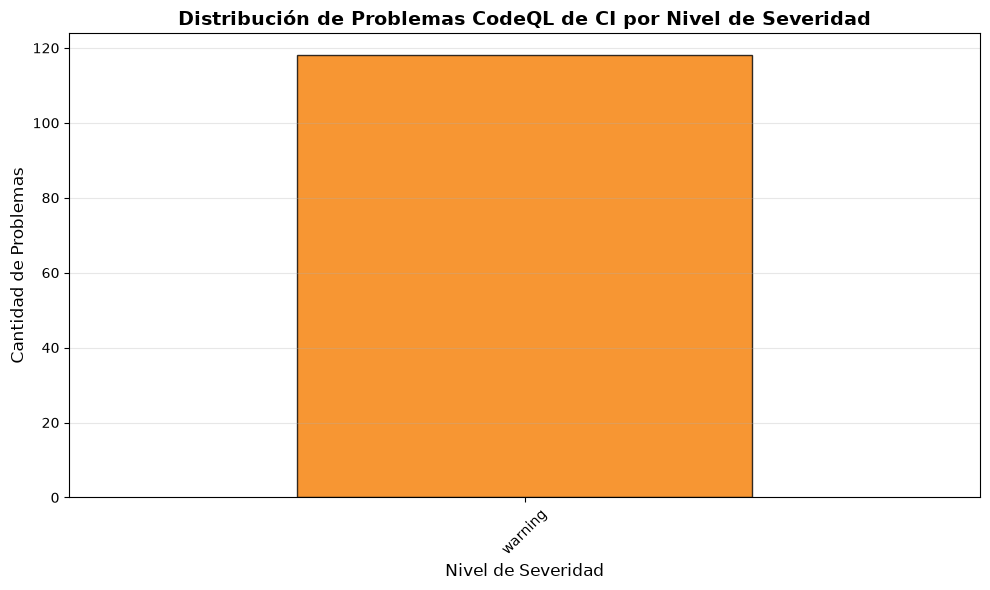

In [47]:
# Gráfico: Distribución por severidad
if len(df_codeql) > 0:
    fig, ax = plt.subplots(figsize=(10, 6))

    stats_severity = df_codeql['level'].value_counts(
    ).sort_index(ascending=False)

    colores = {'error': '#d32f2f', 'warning': '#f57c00', 'note': '#7cb342'}
    color_list = [colores.get(nivel, '#757575')
                  for nivel in stats_severity.index]

    stats_severity.plot(kind='bar', ax=ax, color=color_list,
                        edgecolor='black', alpha=0.8)

    ax.set_title('Distribución de Problemas CodeQL de CI por Nivel de Severidad',
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Nivel de Severidad', fontsize=12)
    ax.set_ylabel('Cantidad de Problemas', fontsize=12)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("No hay datos disponibles para graficar")

Posteriormente se detectaron alrededor de 120 problemas en total entre todos los repositorios, donde todos son categorizados por severidad “Warning”.

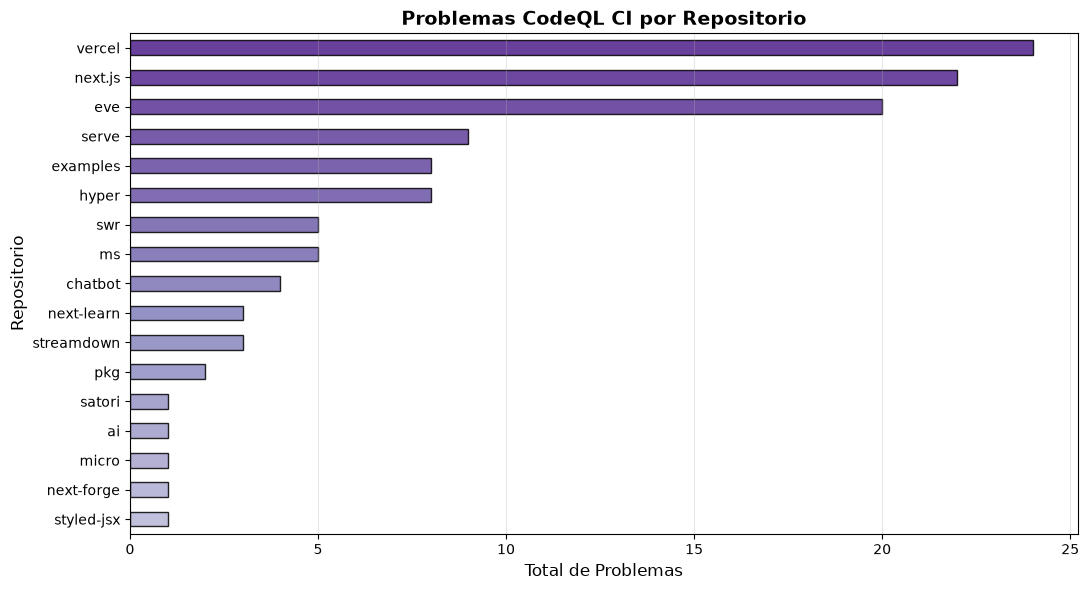

Datos de CI por repositorio exportados a: /Users/mgci/Universidad/Semestre-8/Ciberseguridad/Proyecto-Ciberseguridad/results/ci-analisis/ci-repo.json


In [48]:
# Gráfico: Problemas por repositorio (CodeQL)
if len(df_codeql) > 0:
    fig, ax = plt.subplots(figsize=(11, 6))

    issues_por_repo = df_codeql['repo'].value_counts().sort_values(ascending=True)

    colores_gradiente = plt.cm.Purples(
        np.linspace(0.4, 0.9, len(issues_por_repo)))

    issues_por_repo.plot(
        kind='barh', ax=ax, color=colores_gradiente, edgecolor='black', alpha=0.85)

    ax.set_title('Problemas CodeQL CI por Repositorio',
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Total de Problemas', fontsize=12)
    ax.set_ylabel('Repositorio', fontsize=12)
    ax.grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()

    df_ci_repo_export = df_codeql['repo'].value_counts().reset_index()
    df_ci_repo_export.columns = ['repo', 'count']

    output_ci_repo_path = RESULTS_FOLDER / "ci-analisis" /"ci-repo.json"
    df_ci_repo_export.to_json(output_ci_repo_path, orient='records', indent=4)
    print(f"Datos de CI por repositorio exportados a: {output_ci_repo_path}")

else:
    print("No hay datos disponibles para graficar")

En el gráfico se presentan las frecuencias ordenadas de mayor a menor de los problemas relacionados a CI, donde destaca el repositorio de vercel, presentando alrededor de 25 problemas, siendo la frecuencia mayor del conjunto. 

In [49]:
# Top 5 reglas más comunes
if len(df_codeql) > 0:
    top_rules = df_codeql['rule_id'].value_counts().head(5)

    print("\nTop 5 Reglas de Seguridad Más Frecuentes:")
    print("=" * 70)
    
    export_ci_rules = []
    
    for idx, (rule, count) in enumerate(top_rules.items(), 1):
        porcentaje = (count / len(df_codeql)) * 100
        print(f"{idx:2d}. {rule:40s} {count:3d} ({porcentaje:5.1f}%)")
        
        export_ci_rules.append({
            "rule_id": rule,
            "count": int(count),
            "percentage": round(porcentaje, 1)
        })

    output_ci_rules_path = RESULTS_FOLDER / "ci-analisis" / "ci-reglas.json"
    with open(output_ci_rules_path, 'w', encoding='utf-8') as f:
        json.dump(export_ci_rules, f, indent=4)
        
    print(f"\nDatos de top reglas CI exportados a: {output_ci_rules_path}")

else:
    print("No hay datos disponibles")


Top 5 Reglas de Seguridad Más Frecuentes:
 1. actions/missing-workflow-permissions      88 ( 74.6%)
 2. actions/unpinned-tag                      24 ( 20.3%)
 3. actions/untrusted-checkout/medium          4 (  3.4%)
 4. actions/code-injection/medium              1 (  0.8%)
 5. actions/unnecessary-use-of-advanced-config   1 (  0.8%)

Datos de top reglas CI exportados a: /Users/mgci/Universidad/Semestre-8/Ciberseguridad/Proyecto-Ciberseguridad/results/ci-analisis/ci-reglas.json


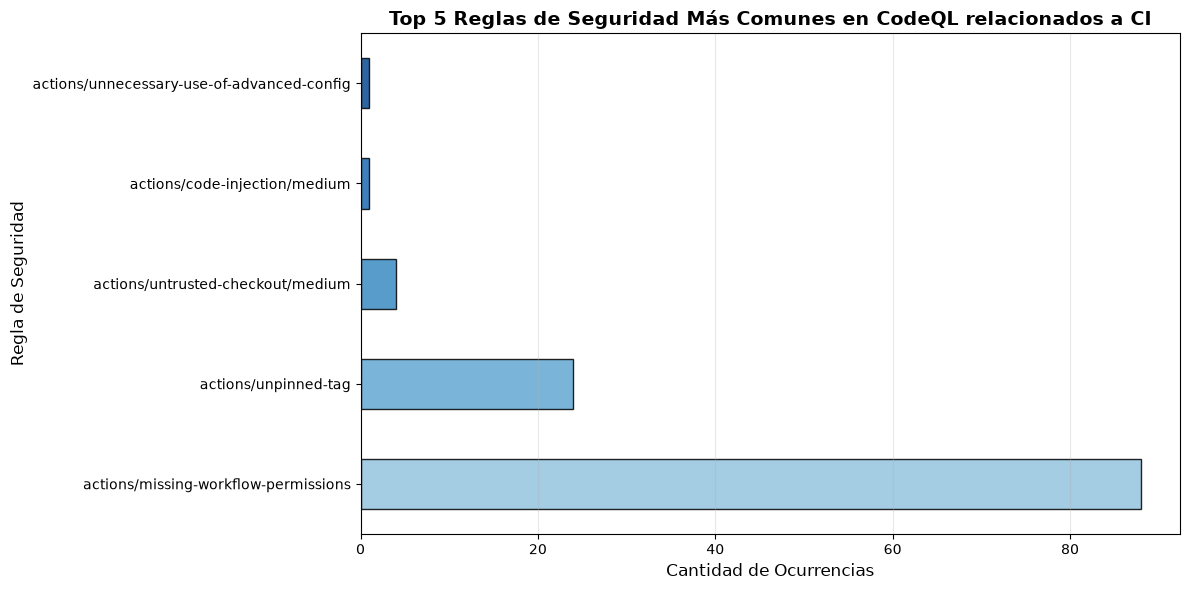

In [50]:
# Gráfico: Top 5 reglas más comunes
if len(df_codeql) > 0:
    fig, ax = plt.subplots(figsize=(12, 6))

    top_rules = df_codeql['rule_id'].value_counts().head(5)

    colores_gradiente = plt.cm.Blues(np.linspace(0.4, 0.9, len(top_rules)))

    top_rules.plot(kind='barh', ax=ax, color=colores_gradiente,
                   edgecolor='black', alpha=0.85)

    ax.set_title('Top 5 Reglas de Seguridad Más Comunes en CodeQL relacionados a CI',
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Cantidad de Ocurrencias', fontsize=12)
    ax.set_ylabel('Regla de Seguridad', fontsize=12)
    ax.grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("No hay datos disponibles para graficar")

Posteriormente se encuentran las 5 reglas más comunes relacionadas a CI:
1. **actions/missing-workflow-permissions:** El problema más frecuente corresponde a no definir verbalmente los permisos que contiene el CI. Por tanto, heredan los permisos de la organización que los creó. Es por ello que se recomienda la definición de los permisos, además de utilizar el principio de mínimo privilegio para minimizar el posible daño.
2. **actions/unpinned-tag:** Hace referencia a asociar acciones a tags, la cual puede no estar fijada, permitiendo la ejecución de una acción no autorizada. Para mitigarlo, se recomienda la utilización del SHA del commit, ya que, es inmutable y única.
3. **actions/unstrusted-checkout/medium:** Utilización de triggers como pull_request_target o issue_comment seguido de un checkout puede permitir la ejecución de código ajeno. Por tanto se recomienda no utilizarlo a menos que sea necesario, utilizar menos privilegios, y usar etiquetas para manejar el contexto de ejecución correctamente.
4. **actions/code-injection/medium:** Hace referencia a permitir el user-input en Github Actions, ya que, puede permitir infiltrar los secrets utilizados u obtener el token de autorización, dando permisos de escritura a agentes externos. Es por ello que se recomienda evitar el user-input en lo posible, y en caso de ser necesario, utilizar una variable de entorno intermedia y después utilizarla como variable en el script. Además de limitar los permisos del token para reducir el posible daño.
5. **actions/unnecessary-use-of-advanced-config:** Corresponde a una recomendación de CodeQL, donde menciona que sí no se utilizan recomendaciones avanzadas, se recomienda dejar la por defecto.